# Structure Formation and LSS

Three sections:
1. **Lagrangian Perturbation Theory (LPT)** — Gaussian Random Field, 1LPT vs 2LPT comparison, redshift evolution, power spectrum validation
2. **Effective Field Theory (EFT)** — 1-loop EFT power spectrum and bias model *(planned — see [issue #6](https://github.com/sambit-giri/toolscosmo/issues/6))*
3. **21cm GRF simulations** — cosmological parameter dependence

---
## Part 1 — Lagrangian Perturbation Theory (LPT)

### 1a. Setup and Gaussian Random Field

Using CAMB to estimate linear power spectrum.
sigma_8=0.811
CAMB runtime: 0.19 s
Generating Gaussian random field...
...done in 0.116 seconds
Preparing cosmological solvers...
...done
Displacing particles using 2LPT...
...done in 4.111 seconds
Displacing particles using 2LPT...
...done in 3.380 seconds

Using PCS mass assignment scheme
Time taken = 0.051 seconds


Using PCS mass assignment scheme
Time taken = 0.050 seconds



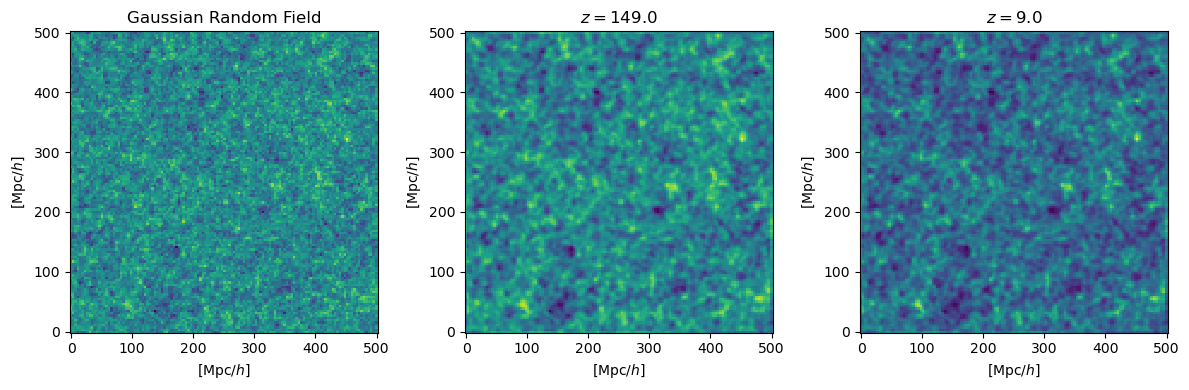

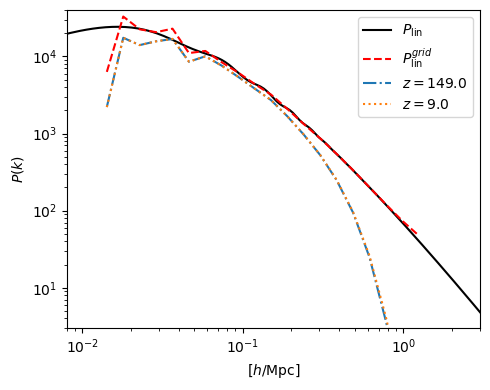

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import toolscosmo as tcm
import tools21cm as t2c

grid_size = 128 #512 #
box_size  = 500 #Mpc/h 
param = tcm.par()
param.file.ps = 'CAMB' # 'CLASS' 'CLASSemu'
param.file.ps = tcm.get_Plin(param)
iSeed = 314159265

z1 = 149.
z2 = 9.

delta_lin = tcm.generate_gaussian_random_field(grid_size, box_size, param=param, random_seed=iSeed)['delta_lin']
particle_pos_z1 = tcm.generate_initial_condition_positions(grid_size, box_size, z1, param, LPT=2, delta_lin=delta_lin)['positions']
particle_pos_z2 = tcm.generate_initial_condition_positions(grid_size, box_size, z2, param, LPT=2, delta_lin=delta_lin)['positions']
delta_z1 = tcm.particles_on_grid(particle_pos_z1, grid_size, box_size)
delta_z2 = tcm.particles_on_grid(particle_pos_z2, grid_size, box_size)

fig, axs = plt.subplots(1,3,figsize=(12,4))
axs[0].set_title('Gaussian Random Field')
xx = np.linspace(0,box_size,grid_size)
axs[0].pcolor(xx, xx, delta_lin[:,:,grid_size//2])
xx = np.linspace(0,box_size,grid_size)
axs[1].set_title(f'$z={z1}$')
axs[1].pcolor(xx, xx, delta_z1[:,:,grid_size//2])
axs[2].set_title(f'$z={z2}$')
axs[2].pcolor(xx, xx, delta_z2[:,:,grid_size//2])
for ax in axs.flatten():
    ax.set_xlabel('[Mpc/$h$]')
    ax.set_ylabel('[Mpc/$h$]')
plt.tight_layout()
plt.show()

ps0 = t2c.power_spectrum_1d(delta_lin, kbins=20, box_dims=box_size)
ps1 = t2c.power_spectrum_1d(delta_z1, kbins=20, box_dims=box_size)
ps2 = t2c.power_spectrum_1d(delta_z2, kbins=20, box_dims=box_size)
p0, k0 = ps0
p1, k1 = ps1[0]/tcm.growth_factor(z1, param)**2, ps1[1]
p2, k2 = ps2[0]/tcm.growth_factor(z2, param)**2, ps2[1]

fig, ax = plt.subplots(1,1,figsize=(5,4))
kk, pp = param.file.ps['k'], param.file.ps['P']
ax.loglog(kk, pp, c='k', ls='-', label='$P_\mathrm{{lin}}$')
ax.loglog(k0, p0, c='r', ls='--', label='$P^{{grid}}_\mathrm{{lin}}$')
ax.loglog(k1, p1*(grid_size/box_size)**-1, c='C0', ls='-.', label=f'$z={z1}$')
ax.loglog(k2, p2*(grid_size/box_size)**-1, c='C1', ls=':', label=f'$z={z2}$')
ax.set_xlabel('[$h$/Mpc]')
ax.set_ylabel('$P(k)$')
ax.axis([8e-3,3,3,4e4])
ax.legend()
plt.tight_layout()
plt.show()

### 1b. 1LPT vs 2LPT comparison at fixed redshift

At the same redshift, 1LPT (Zel'dovich approximation) and 2LPT differ in how they handle
the displacement field — 2LPT includes the tidal corrections that improve the accuracy
of halo positions and the density field on mildly non-linear scales.

Displacing particles using 1LPT...
...done in 0.709 seconds
Displacing particles using 2LPT...
...done in 3.460 seconds

Using PCS mass assignment scheme
Time taken = 0.051 seconds


Using PCS mass assignment scheme
Time taken = 0.051 seconds



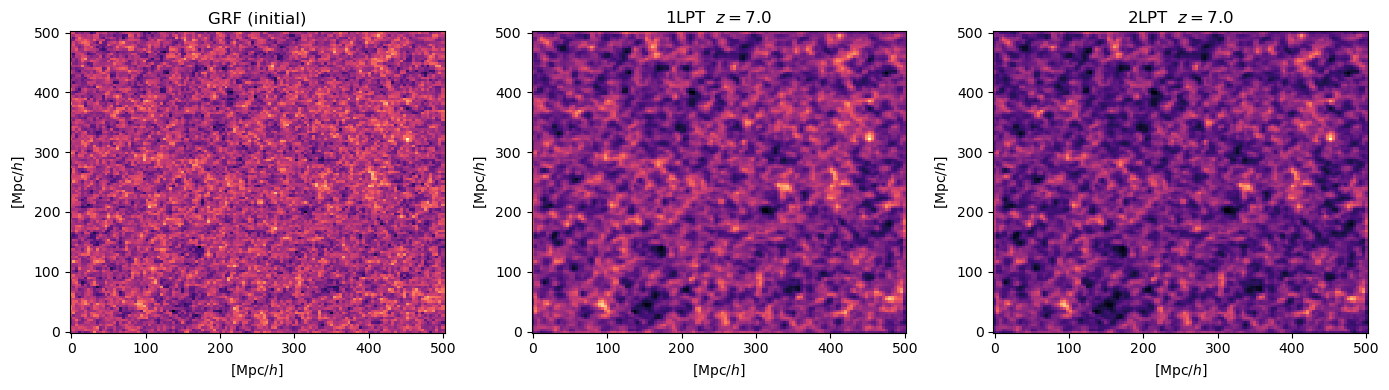

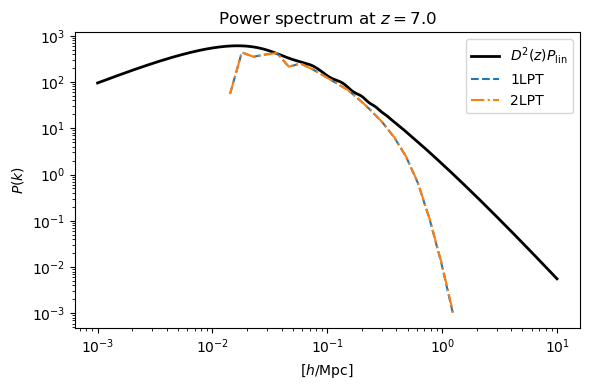

In [2]:
z_comp = 7.0   # comparison redshift

pos_1lpt = tcm.generate_initial_condition_positions(grid_size, box_size, z_comp, param, LPT=1, delta_lin=delta_lin)['positions']
pos_2lpt = tcm.generate_initial_condition_positions(grid_size, box_size, z_comp, param, LPT=2, delta_lin=delta_lin)['positions']

delta_1lpt = tcm.particles_on_grid(pos_1lpt, grid_size, box_size)
delta_2lpt = tcm.particles_on_grid(pos_2lpt, grid_size, box_size)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
xx = np.linspace(0, box_size, grid_size)
sl = grid_size // 2

for ax, field, title in zip(axs,
                             [delta_lin, delta_1lpt, delta_2lpt],
                             ['GRF (initial)', f'1LPT  $z={z_comp}$', f'2LPT  $z={z_comp}$']):
    ax.pcolor(xx, xx, field[:, :, sl], cmap='magma')
    ax.set_title(title)
    ax.set_xlabel('[Mpc/$h$]')
    ax.set_ylabel('[Mpc/$h$]')

plt.tight_layout()
plt.show()

# Power spectrum comparison
ps_1lpt = t2c.power_spectrum_1d(delta_1lpt, kbins=20, box_dims=box_size)
ps_2lpt = t2c.power_spectrum_1d(delta_2lpt, kbins=20, box_dims=box_size)

fig, ax = plt.subplots(figsize=(6, 4))
kk, pp = param.file.ps['k'], param.file.ps['P']
D_z = tcm.growth_factor(z_comp, param)
ax.loglog(kk, pp * D_z**2, c='k', ls='-',  lw=2, label='$D^2(z) P_\mathrm{lin}$')
ax.loglog(ps_1lpt[1], ps_1lpt[0] * (grid_size / box_size)**-1, c='C0', ls='--', label='1LPT')
ax.loglog(ps_2lpt[1], ps_2lpt[0] * (grid_size / box_size)**-1, c='C1', ls='-.',  label='2LPT')
ax.set_xlabel('[$h$/Mpc]')
ax.set_ylabel('$P(k)$')
ax.set_title(f'Power spectrum at $z={z_comp}$')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — Effective Field Theory (EFT) of LSS

> **Work in progress** — see [sambit-giri/toolscosmo#6](https://github.com/sambit-giri/toolscosmo/issues/6).
>
> Planned: 1-loop EFT power spectrum, bias parameters (b1, b2, bG2, bΓ3), RSD multipoles (P0, P2, P4), Anastasiou 2024 and Qin 2022 formulations.

This section will be extended once the EFT module is complete.

---
## Part 3 — 21cm GRF Simulations

Gaussian Random Field 21cm signal with cosmological parameter variations.

Using CAMB to estimate linear power spectrum.
sigma_8=0.718
CAMB runtime: 0.20 s
Generating Gaussian random field...
...done in 0.091 seconds
Using CAMB to estimate linear power spectrum.
sigma_8=0.718
CAMB runtime: 0.19 s
Generating Gaussian random field...
...done in 0.090 seconds
Using CAMB to estimate linear power spectrum.
sigma_8=0.782
CAMB runtime: 0.18 s
Generating Gaussian random field...
...done in 0.088 seconds
Using CAMB to estimate linear power spectrum.
sigma_8=0.782
CAMB runtime: 0.18 s
Generating Gaussian random field...
...done in 0.086 seconds


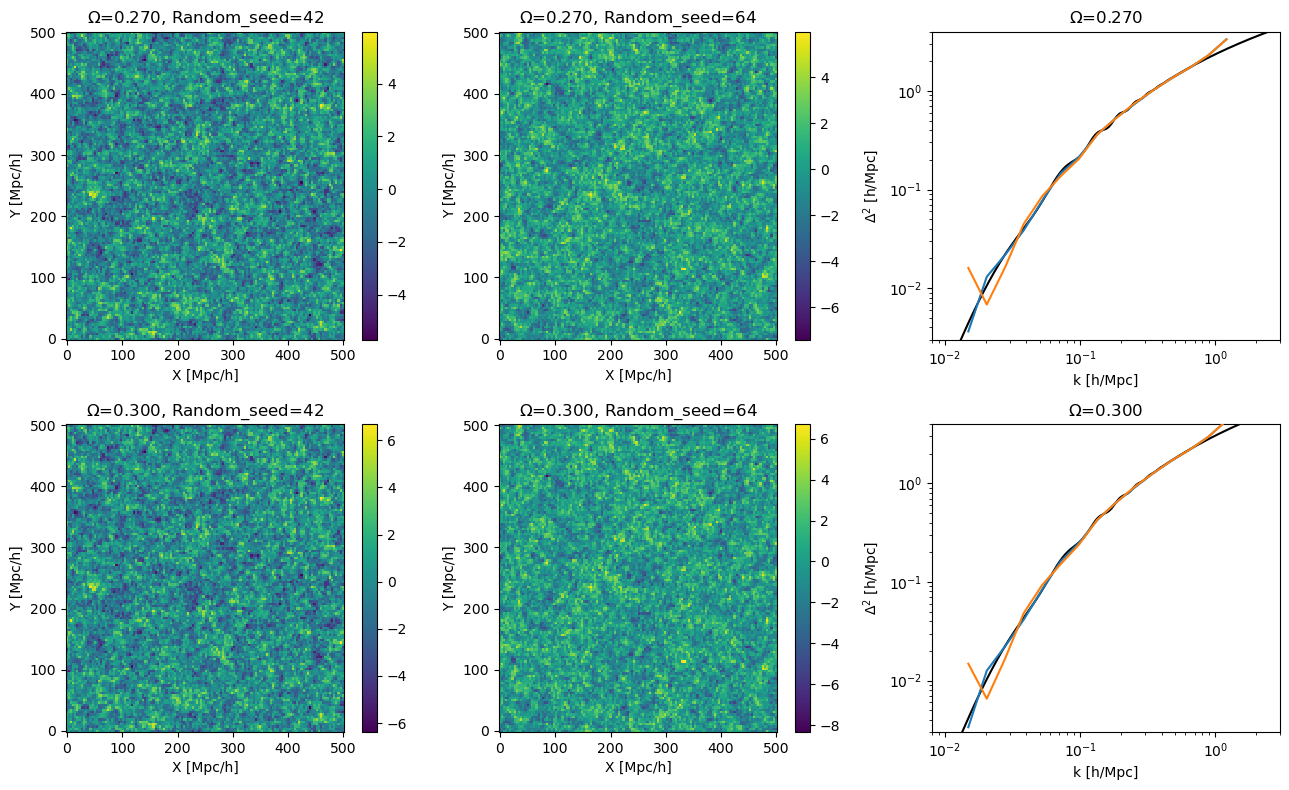

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import toolscosmo as tcm
import tools21cm as t2c

def simulate_delta_GRF(Om=0.315, Ob=0.049, Or=5.4e-05, As=2.089e-09, h0=0.673, ns=0.963, iSeed=42, grid_size=128, box_size=500):
    """
    Generate Gaussian Random Field (GRF) from matter power spectrum.

    Parameters:
    -----------
    Om : float
        Matter density parameter.
    Ob : float
        Baryon density parameter.
    Or : float
        Radiation density parameter.
    As : float
        Amplitude of the primordial power spectrum.
    h0 : float
        Hubble parameter.
    ns : float
        Spectral index of the primordial power spectrum.
    iSeed : int, optional
        Random seed for reproducibility (default is 42).
    grid_size : int, optional
        Size of the grid for the simulation (default is 128).
    box_size : int, optional
        Size of the simulation box (default is 500 Mpc/h).

    Returns:
    --------
    dict
        A dictionary containing:
        - delta_lin : np.ndarray
            Linear density field in real space.
        - PS : np.ndarray
            Matter power spectrum.
    """
    param = tcm.par()
    param.cosmo.Om = Om
    param.cosmo.Ob = Ob
    param.cosmo.Or = Or
    param.cosmo.Ok = 0.
    param.cosmo.As = As
    param.cosmo.h0 = h0
    param.cosmo.ns = ns
    param.file.ps = 'CAMB' # 'CLASS' 'CLASSemu'
    param.file.ps = tcm.get_Plin(param)
    delta_lin = tcm.generate_gaussian_random_field(grid_size, box_size, param=param, random_seed=iSeed)['delta_lin']
    return {'delta_lin': delta_lin, 'PS': param.file.ps}

def simulate_21cm_GRF(z=9., Om=0.315, Ob=0.049, Or=5.4e-05, As=2.089e-09, h0=0.673, ns=0.963, iSeed=42, grid_size=128, box_size=500):
    """
    Generate Gaussian Random Field (GRF) from matter power spectrum.

    Parameters:
    -----------
    z : float
        Redshift.
    Om : float
        Matter density parameter.
    Ob : float
        Baryon density parameter.
    Or : float
        Radiation density parameter.
    As : float
        Amplitude of the primordial power spectrum.
    h0 : float
        Hubble parameter.
    ns : float
        Spectral index of the primordial power spectrum.
    iSeed : int, optional
        Random seed for reproducibility (default is 42).
    grid_size : int, optional
        Size of the grid for the simulation (default is 128).
    box_size : int, optional
        Size of the simulation box (default is 500 Mpc/h).

    Returns:
    --------
    dict
        A dictionary containing:
        - delta_lin : np.ndarray
            Linear density field in real space.
        - PS : np.ndarray
            Matter power spectrum.
        - dt21 : np.ndarray
            21cm brightness temperature.
    """
    grf_mod = simulate_delta_GRF(Om=Om, Ob=Ob, Or=Or, As=As, h0=h0, ns=ns, iSeed=iSeed, grid_size=grid_size, box_size=box_size)
    dt21 = t2c.mean_dt(z)*(1+grf_mod['delta_lin'])
    grf_mod['dt21'] = dt21
    return grf_mod

if __name__ == "__main__":
    grid_size = 128
    box_size  = 500 #Mpc/h

    Om_list = [0.27, 0.30]
    iSeed_list = [42, 64]

    fig, axs = plt.subplots(2,3,figsize=(13,8))
    xx = np.linspace(0,box_size,grid_size)
    for i,Om in enumerate(Om_list):
        for j,iSeed in enumerate(iSeed_list):
            grf_mod = simulate_21cm_GRF(Om=Om, iSeed=iSeed, grid_size=grid_size, box_size=box_size)
            ps, ks = t2c.power_spectrum_1d(grf_mod['delta_lin'], kbins=15, box_dims=box_size)
            axs[i,j].set_title(r'$\Omega$=%.3f, Random_seed=%d'%(Om,iSeed))
            im = axs[i,j].pcolor(xx, xx, grf_mod['delta_lin'][10])
            axs[i,j].set_xlabel('X [Mpc/h]')
            axs[i,j].set_ylabel('Y [Mpc/h]')
            fig.colorbar(im, ax=axs[i,j])
            axs[i,-1].set_title(r'$\Omega$=%.3f'%(Om))
            axs[i,-1].loglog(ks, ps*ks**3/2/np.pi**2, c=f'C{j}', label=r'Random_seed=%d'%iSeed, zorder=3)
        ps, ks = grf_mod['PS']['P'], grf_mod['PS']['k']
        axs[i,-1].loglog(ks, ps*ks**3/2/np.pi**2, c='k', label=r'CLASSemu', zorder=1)
        axs[i,-1].axis([8e-3,3,3e-3,4])
        axs[i,-1].set_xlabel('k [h/Mpc]')
        axs[i,-1].set_ylabel(r'$\Delta^2$ [h/Mpc]')
    plt.tight_layout()
    plt.show()
            